# 🚦 Traffic Sign Detection Pipeline

A complete classical computer vision pipeline for detecting traffic signs, structured into three stages:

| Stage | Description |
|---|---|
| **1 — Ground Truth Generation** | Build bounding-box annotations from Kaggle metadata, with augmented-filename support |
| **2 — Detection Pipeline** | HSV color masking + contour analysis → predicted bounding boxes |
| **3 — Evaluation** | Intersection over Union (IoU) scoring and visualisation |

---


## ⚙️ 0 — Global Configuration

Shared paths and constants used across all pipeline stages.


In [3]:
INPUT_DIR        = "processed_dataset"
OUTPUT_DIR       = "detections_v2"
SPLITS           = ["train", "val", "test"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


---

## 📦 Section 1 — Ground Truth Generation

Generates a CSV of bounding-box annotations for every image in the dataset.

### Strategy — Pseudo Ground Truth
When real labels are unavailable, we define a **centred box covering 70 % of each image** (with a 15 % inset from each edge). This gives a reasonable baseline for evaluation.

### Alternative — Kaggle Annotations
A second implementation (in the cell that follows) loads the official `Train.csv` / `Test.csv` from Kaggle and maps them back to augmented images by stripping the `_aug` suffix.

> **Output:** `detections_v2/pseudo_ground_truth.csv`


In [4]:
import os
import csv
import cv2

GT_CSV_NAME = "pseudo_ground_truth.csv"


def is_image_file(filename):
    return os.path.splitext(filename.lower())[1] in IMAGE_EXTENSIONS


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def get_all_images(split_dir):
    image_paths = []
    for root, _, files in os.walk(split_dir):
        for file in files:
            if is_image_file(file):
                image_paths.append(os.path.join(root, file))
    return sorted(image_paths)


def create_pseudo_box(image_w, image_h):
    x = int(image_w * 0.15)
    y = int(image_h * 0.15)
    w = int(image_w * 0.70)
    h = int(image_h * 0.70)
    return x, y, w, h


def process_split_for_gt(split_name, writer):
    input_split_dir = os.path.join(INPUT_DIR, split_name)

    if not os.path.isdir(input_split_dir):
        print(f"Skipped missing folder: {input_split_dir}")
        return

    for input_path in get_all_images(input_split_dir):
        image = cv2.imread(input_path)
        if image is None:
            print(f"Failed to read: {input_path}")
            continue

        image_h, image_w = image.shape[:2]
        x, y, w, h = create_pseudo_box(image_w, image_h)

        relative_path = os.path.relpath(input_path, input_split_dir)
        csv_image_path = f"{split_name}/{relative_path.replace(os.sep, '/')}"

        writer.writerow([csv_image_path, x, y, w, h])
        print(f"Pseudo GT: {csv_image_path}  →  x={x}, y={y}, w={w}, h={h}")


def generate_pseudo_ground_truth():
    ensure_dir(OUTPUT_DIR)
    csv_path = os.path.join(OUTPUT_DIR, GT_CSV_NAME)

    with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["image_path", "x", "y", "w", "h"])
        for split_name in SPLITS:
            process_split_for_gt(split_name, writer)

    print(f"\n Done — pseudo ground truth saved to: {csv_path}")


generate_pseudo_ground_truth()


Pseudo GT: train/0/00000_00000_00000.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00000_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00002.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00002_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00003.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00003_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00004.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00004_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00006.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00006_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00008.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00008_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00009.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00009_aug0.png  →  x=9, y=9, w=44, h=44
Pseudo GT: train/0/00000_00000_00010.png 

### 🔄 Alternative: Ground Truth from Kaggle Annotations

Loads real bounding boxes from `Train.csv` / `Test.csv` and handles augmented images by
stripping the `_aug` suffix before lookup.




In [20]:
import pandas as pd


def strip_augmentation_suffix(filename):
    if "_aug" in filename:
        base_name = filename.split("_aug")[0]
        ext = os.path.splitext(filename)[1]
        return base_name + ext
    return filename


def generate_kaggle_ground_truth():
    ensure_dir(OUTPUT_DIR)

    try:
        kaggle_df = pd.concat([pd.read_csv("Train.csv"), pd.read_csv("Test.csv")])
    except FileNotFoundError:
        print("❌  Train.csv / Test.csv not found. Place them in the working directory.")
        return

    gt_lookup = {
        os.path.basename(row["Path"]): (
            int(row["Roi.X1"]),
            int(row["Roi.Y1"]),
            int(row["Roi.X2"] - row["Roi.X1"]),
            int(row["Roi.Y2"] - row["Roi.Y1"]),
        )
        for _, row in kaggle_df.iterrows()
    }

    csv_path = os.path.join(OUTPUT_DIR, GT_CSV_NAME)
    with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["image_path", "x", "y", "w", "h"])

        for split_name in SPLITS:
            input_split_dir = os.path.join(INPUT_DIR, split_name)
            if not os.path.isdir(input_split_dir):
                continue

            for input_path in get_all_images(input_split_dir):
                filename        = os.path.basename(input_path)
                relative_path   = os.path.relpath(input_path, input_split_dir)
                csv_image_path  = f"{split_name}/{relative_path.replace(os.sep, '/')}"
                canonical_name  = strip_augmentation_suffix(filename)
                box             = gt_lookup.get(canonical_name, (0, 0, 0, 0))
                writer.writerow([csv_image_path, *box])

    print(f"Done — Kaggle ground truth saved to: {csv_path}")



---

## 🔍 Section 2 — Detection Pipeline

Runs the full object detection pipeline across all dataset splits using classical computer vision.

### How it works

1. **Colour masking** — Convert to HSV and threshold for red (two hue ranges) and blue.
2. **Mask cleaning** — Gaussian blur → morphological open → morphological close.
3. **Contour scoring** — For each contour passing area and aspect-ratio filters, compute:  
   `score = bounding_rect_area × fill_ratio`  
   The contour with the highest score becomes the detection box.
4. **Fallback** — If nothing is detected, the full image bounds are written to CSV.

### Output
| Artifact | Location |
|---|---|
| Annotated images | `detections_v2/{split}/` |
| Binary colour masks | `detections_v2/{split}_masks/` |
| Predictions CSV | `detections_v2/detection_results_eval.csv` |


In [6]:
import numpy as np

DETECTION_CSV_NAME  = "detection_results_eval.csv"
MIN_CONTOUR_AREA    = 300
MIN_ASPECT_RATIO    = 0.6
MAX_ASPECT_RATIO    = 1.8
MAX_IMAGE_AREA_RATIO = 0.9

RED_HSV_RANGES = [
    ((0,   70, 50), (10,  255, 255)),
    ((170, 70, 50), (180, 255, 255)),
]

BLUE_HSV_RANGE = ((90, 60, 40), (140, 255, 255))


In [7]:
def build_color_mask(hsv_image):
    red_mask = np.zeros(hsv_image.shape[:2], dtype=np.uint8)
    for lower, upper in RED_HSV_RANGES:
        red_mask |= cv2.inRange(
            hsv_image,
            np.array(lower, dtype=np.uint8),
            np.array(upper, dtype=np.uint8),
        )

    blue_mask = cv2.inRange(
        hsv_image,
        np.array(BLUE_HSV_RANGE[0], dtype=np.uint8),
        np.array(BLUE_HSV_RANGE[1], dtype=np.uint8),
    )

    combined = cv2.bitwise_or(red_mask, blue_mask)
    combined = cv2.GaussianBlur(combined, (5, 5), 0)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    return combined


def detect_sign_bbox(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask      = build_color_mask(hsv_image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    image_h, image_w = image.shape[:2]
    image_area = image_h * image_w
    best_box   = None
    best_score = -1

    for contour in contours:
        area = cv2.contourArea(contour)
        if area < MIN_CONTOUR_AREA:
            continue

        hull = cv2.convexHull(contour)
        x, y, w, h = cv2.boundingRect(hull)
        rect_area = w * h
        if rect_area <= 0:
            continue

        fill_ratio   = area / rect_area
        aspect_ratio = w / float(h)

        if rect_area > image_area * MAX_IMAGE_AREA_RATIO:
            continue
        if not (MIN_ASPECT_RATIO <= aspect_ratio <= MAX_ASPECT_RATIO):
            continue

        score = rect_area * fill_ratio
        if score > best_score:
            best_score = score
            best_box   = (x, y, w, h)

    return best_box, mask


def draw_detection_box(image, box):
    annotated = image.copy()
    if box is not None:
        x, y, w, h = box
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return annotated


In [ ]:
def process_split_for_detection(split_name, writer):
    input_split_dir = os.path.join(INPUT_DIR, split_name)
    output_split_dir = os.path.join(OUTPUT_DIR, split_name)
    mask_split_dir   = os.path.join(OUTPUT_DIR, f"{split_name}_masks")

    ensure_dir(output_split_dir)
    ensure_dir(mask_split_dir)

    if not os.path.isdir(input_split_dir):
        print(f"Skipped missing folder: {input_split_dir}")
        return

    for input_path in get_all_images(input_split_dir):
        image = cv2.imread(input_path)
        if image is None:
            print(f"Failed to read: {input_path}")
            continue

        relative_path  = os.path.relpath(input_path, input_split_dir)
        filename       = os.path.basename(relative_path)
        relative_subdir = os.path.dirname(relative_path)

        ensure_dir(os.path.join(output_split_dir, relative_subdir))
        ensure_dir(os.path.join(mask_split_dir,   relative_subdir))

        box, mask         = detect_sign_bbox(image)
        annotated_image   = draw_detection_box(image, box)
        csv_image_path    = f"{split_name}/{relative_path.replace(os.sep, '/')}"

        cv2.imwrite(os.path.join(output_split_dir, relative_subdir, filename), annotated_image)
        cv2.imwrite(os.path.join(mask_split_dir,   relative_subdir, filename), mask)

        if box is not None:
            x, y, w, h = box
            writer.writerow([csv_image_path, x, y, w, h])
            print(f"✔ Detected : {csv_image_path}  →  x={x}, y={y}, w={w}, h={h}")
        else:
            image_h, image_w = image.shape[:2]
            writer.writerow([csv_image_path, 0, 0, image_w, image_h])
            print(f"✘ No detection : {csv_image_path}")


def run_detection_pipeline():
    ensure_dir(OUTPUT_DIR)
    csv_path = os.path.join(OUTPUT_DIR, DETECTION_CSV_NAME)

    with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["image_path", "x", "y", "w", "h"])
        for split_name in SPLITS:
            process_split_for_detection(split_name, writer)

    print(f"\n✅ Done — predictions saved to: {csv_path}")


run_detection_pipeline()


✔ Detected : train/0/00000_00000_00000.png  →  x=3, y=0, w=55, h=55
✔ Detected : train/0/00000_00000_00000_aug0.png  →  x=0, y=0, w=57, h=55
✘ No detection : train/0/00000_00000_00002.png
✔ Detected : train/0/00000_00000_00002_aug0.png  →  x=0, y=0, w=56, h=55
✔ Detected : train/0/00000_00000_00003.png  →  x=0, y=0, w=59, h=61
✔ Detected : train/0/00000_00000_00003_aug0.png  →  x=0, y=0, w=61, h=54
✔ Detected : train/0/00000_00000_00004.png  →  x=0, y=0, w=61, h=57
✘ No detection : train/0/00000_00000_00004_aug0.png
✔ Detected : train/0/00000_00000_00006.png  →  x=0, y=0, w=64, h=57
✘ No detection : train/0/00000_00000_00006_aug0.png
✔ Detected : train/0/00000_00000_00008.png  →  x=0, y=0, w=64, h=55
✔ Detected : train/0/00000_00000_00008_aug0.png  →  x=0, y=0, w=64, h=56
✘ No detection : train/0/00000_00000_00009.png
✔ Detected : train/0/00000_00000_00009_aug0.png  →  x=8, y=0, w=56, h=64
✘ No detection : train/0/00000_00000_00010.png
✘ No detection : train/0/00000_00000_00010_aug0.pn

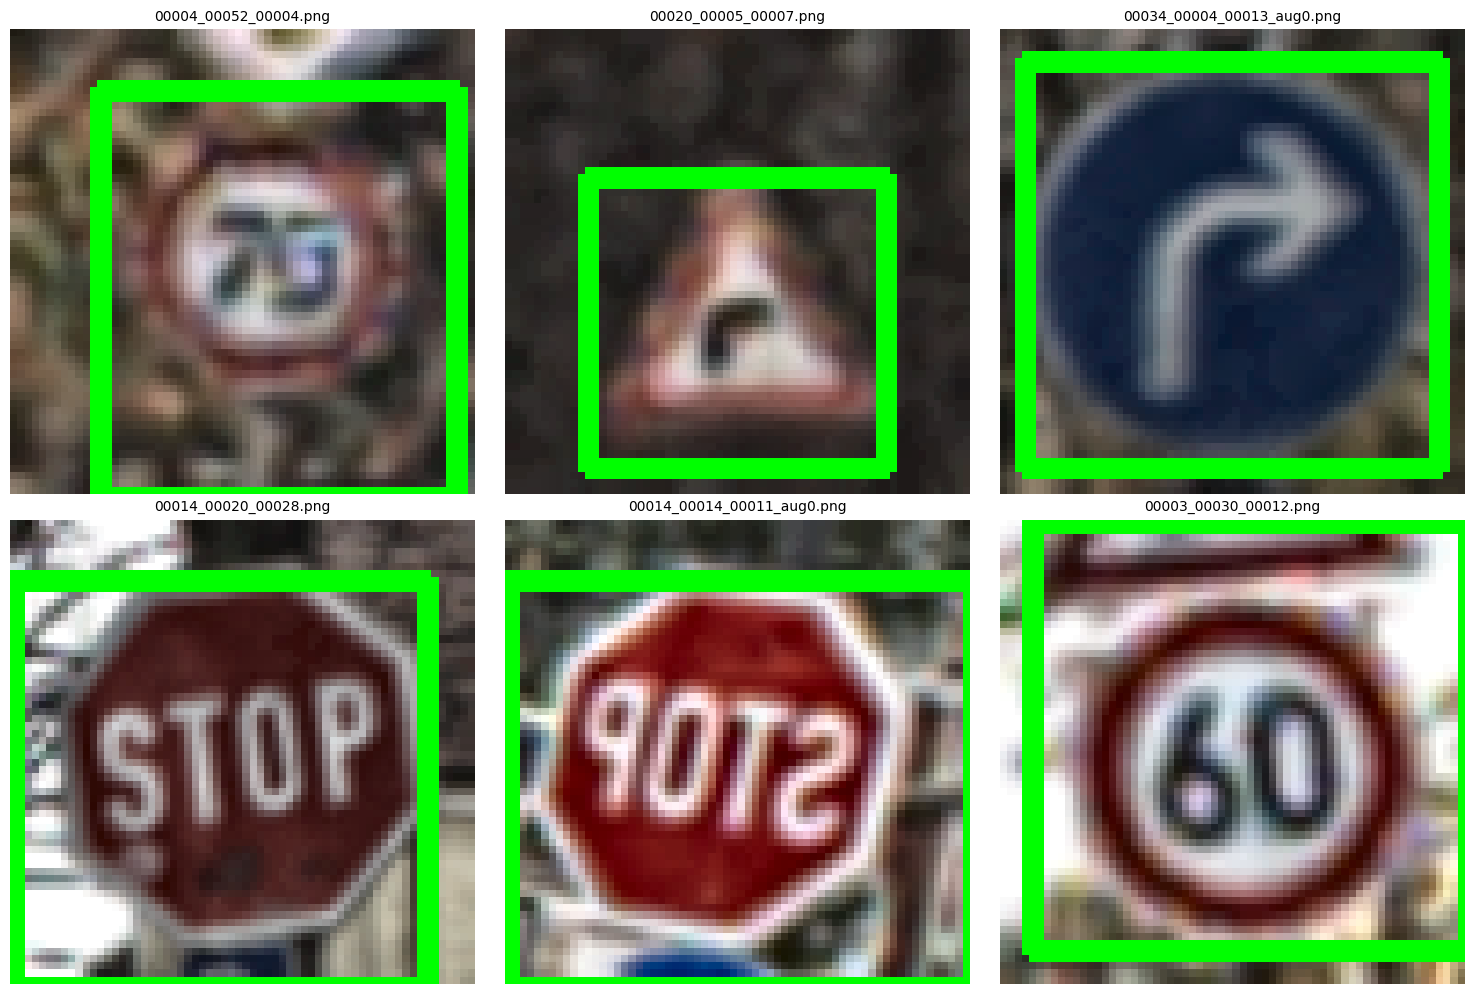

In [19]:
import os
import random
import cv2
import pandas as pd
import matplotlib.pyplot as plt

def show_only_successful_detections(base_dir="detections_v2", csv_name="detection_results_eval.csv", split="train", num_images=6):
    csv_path = os.path.join(base_dir, csv_name)
    df = pd.read_csv(csv_path)
    
    df_split = df[df['image_path'].str.startswith(f"{split}/")]
    df_success = df_split[(df_split['x'] > 0) | (df_split['y'] > 0)]
    successful_images = df_success['image_path'].tolist()
    
    if not successful_images:
        print(f"No successful detections found in the '{split}' split!")
        return

    samples = random.sample(successful_images, min(num_images, len(successful_images)))
    
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes]
    
    for i, img_rel_path in enumerate(samples):
        img_path = os.path.join(base_dir, img_rel_path)
        img = cv2.imread(img_path)
        
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(img_path), fontsize=10)
            axes[i].axis('off')
            
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

show_only_successful_detections(split="train", num_images=6)

---

## 📊 Section 3 — Evaluation

Compares predicted boxes against ground truth using **Intersection over Union (IoU)**.

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

| IoU | Interpretation |
|---|---|
| `1.0` | Perfect overlap |
| `≥ 0.5` | Commonly accepted as a true detection |
| `0.0` | No overlap at all |

**Input files:**
- `detections_v2/detection_results_eval.csv` — model predictions
- `detections_v2/pseudo_ground_truth.csv` — ground truth annotations


In [9]:
import pandas as pd
import os

def calculate_iou(box_a, box_b):
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[0] + box_a[2], box_b[0] + box_b[2])
    inter_y2 = min(box_a[1] + box_a[3], box_b[1] + box_b[3])

    intersection_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    union_area        = box_a[2] * box_a[3] + box_b[2] * box_b[3] - intersection_area

    return 0.0 if union_area == 0 else intersection_area / union_area


def evaluate_detections():
    pred_df = pd.read_csv(os.path.join(OUTPUT_DIR, DETECTION_CSV_NAME))
    gt_df   = pd.read_csv(os.path.join(OUTPUT_DIR, GT_CSV_NAME))

    iou_scores = [
        calculate_iou(
            tuple(pred_df.iloc[i][["x", "y", "w", "h"]]),
            tuple(gt_df.iloc[i][["x", "y", "w", "h"]]),
        )
        for i in range(len(pred_df))
    ]

    average_iou    = sum(iou_scores) / len(iou_scores)
    detection_rate = sum(s >= 0.5 for s in iou_scores) / len(iou_scores)

    print(f"{'Total images evaluated':<30} {len(iou_scores)}")
    print(f"{'Average IoU':<30} {average_iou:.4f}")
    print(f"{'Min IoU':<30} {min(iou_scores):.4f}")
    print(f"{'Max IoU':<30} {max(iou_scores):.4f}")
    print(f"{'Detection Rate (IoU ≥ 0.5)':<30} {detection_rate:.2%}")

    return average_iou, iou_scores


average_iou, iou_scores = evaluate_detections()


Total images evaluated         14620
Average IoU                    0.5525
Min IoU                        0.0484
Max IoU                        0.9560
Detection Rate (IoU ≥ 0.5)     52.99%


### 📈 IoU Score Distribution


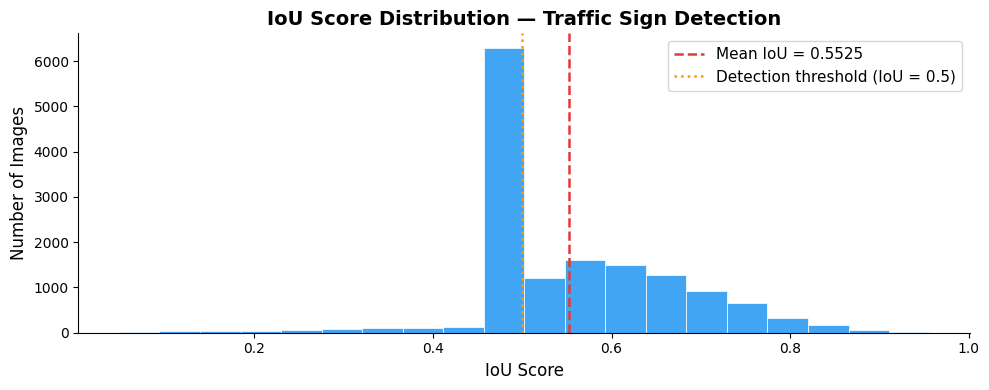

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(iou_scores, bins=20, color="#2196F3", edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(average_iou, color="#E53935", linestyle="--", linewidth=1.8,
            label=f"Mean IoU = {average_iou:.4f}")
ax.axvline(0.5, color="#FF9800", linestyle=":",  linewidth=1.8,
            label="Detection threshold (IoU = 0.5)")

ax.set_xlabel("IoU Score", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("IoU Score Distribution — Traffic Sign Detection", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
